In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
##REad the dataset
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

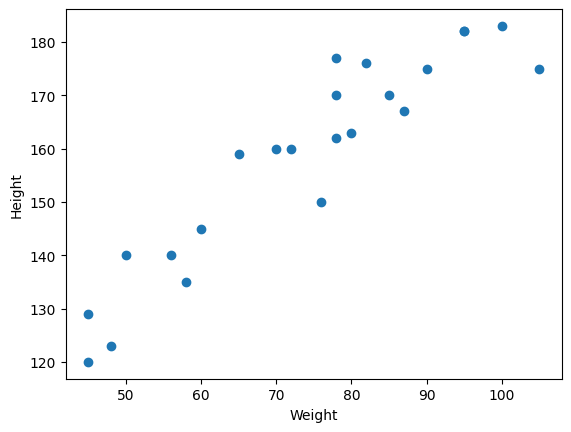

In [4]:
#Scatter Plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [5]:
## Corerlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


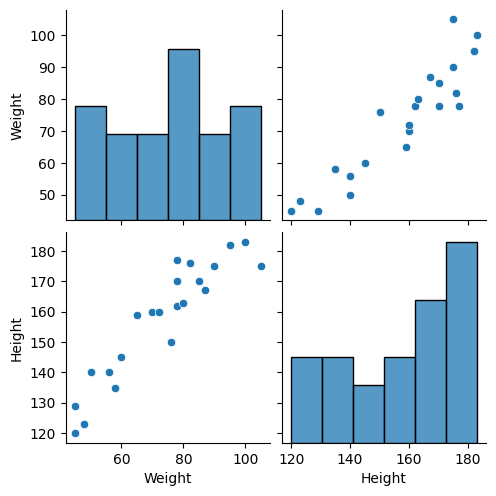

In [6]:
##Seaborn for Visualization
import seaborn as sns
sns.pairplot(df)

In [11]:
## Independent and Dependent Features
X = df[['Weight']] ### Indepent Feature Should be DataFrame or 2D array
y = df['Height'] ### Dependent Feature Should be Series or 1D array

In [12]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [16]:
## Standardize the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
## To avoid data leakage, we fit the scaler only on the training data and then transform both training and test data.

In [19]:
X_train
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

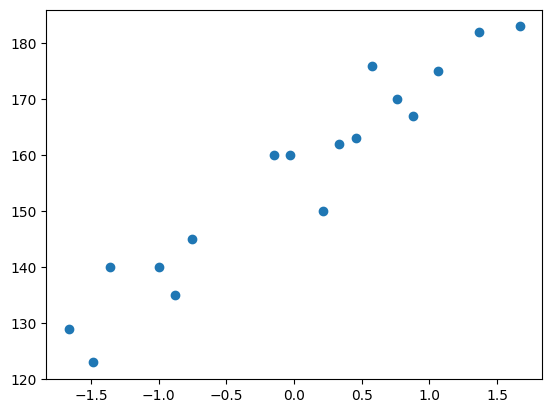

In [20]:
plt.scatter(X_train,y_train)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
regressor=LinearRegression()

In [23]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
type(X_train)

numpy.ndarray

In [26]:
X_train=np.array(X_train).reshape(-1,1)
X_test=np.array(X_test).reshape(-1,1)

In [27]:
y_train.shape

(17,)

In [28]:
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
## coefficient and intercepts
print("Coefficient or Slope: ",regressor.coef_)
print("Intercept : ",regressor.intercept_)

Coefficient :  [17.2982057]
Intercept :  156.47058823529412


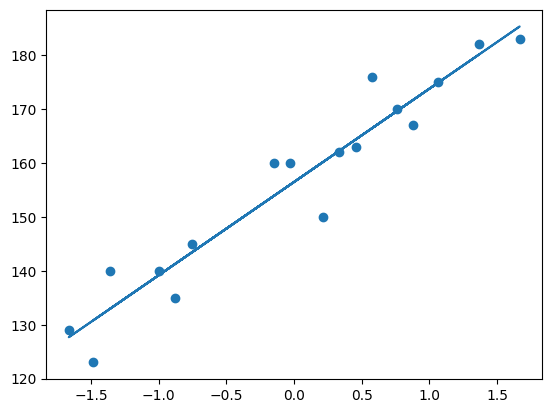

In [30]:
## Plot Training Data as well as Regression Line / Best Fit Line
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train))

### Prediction of Train Data
1. Predicted height output= intercept +coef_(Weights)
2. y_pred_train =156.47058823529412 + 17.2982057(X_train)
          
### Prediction of Test Data
1. Predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.47058823529412 + 17.2982057(X_test)

In [31]:
y_pred_test=regressor.predict(X_test)

In [32]:
y_test

15    177
9     170
0     120
8     182
17    159
12    175
Name: Height, dtype: int64

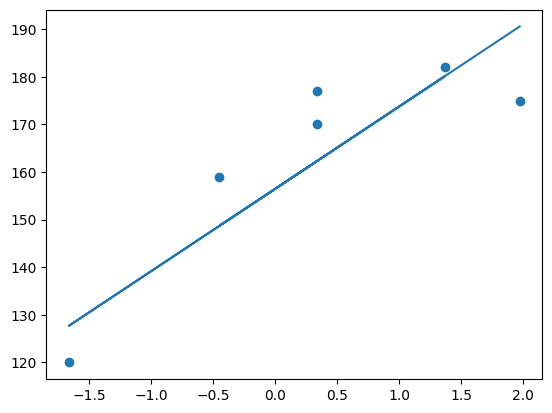

In [33]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test))

In [34]:
### Performance Metrics

from sklearn.metrics import mean_squared_error,mean_absolute_error

In [35]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [38]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)
print(score)

0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [39]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [ ]:
#### Prediction of Test Data
regressor.predict(scaler.transform([[72]]))

c:\Users\Anshul Parkar\Documents\GitHub\Machine_Learning_Algorithms\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

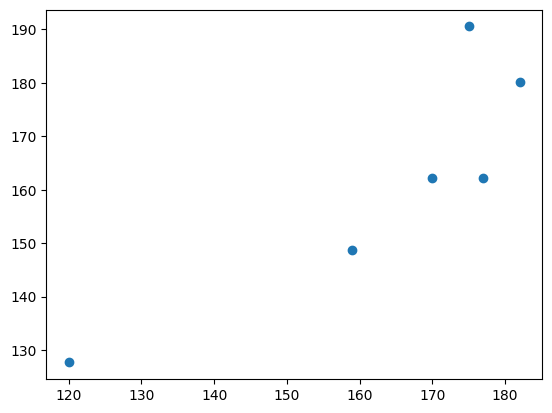

In [48]:
## Assumptions

## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)



In [49]:
## Residuals
residuals=y_test-y_pred_test

residuals



15    14.735003
9      7.735003
0     -7.683471
8      1.920277
17    10.358028
12   -15.558973
Name: Height, dtype: float64

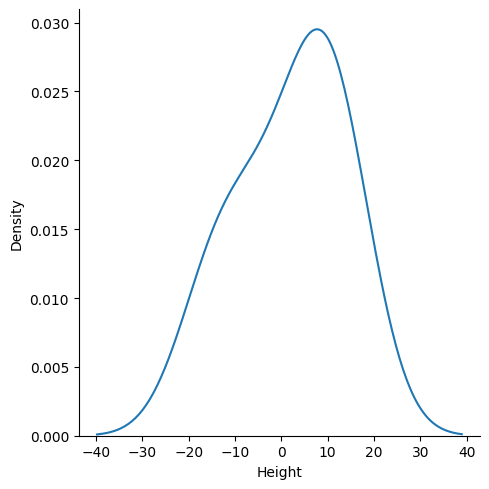

In [50]:
## Plot this residuals 
import seaborn as sns
sns.displot(residuals,kind="kde")



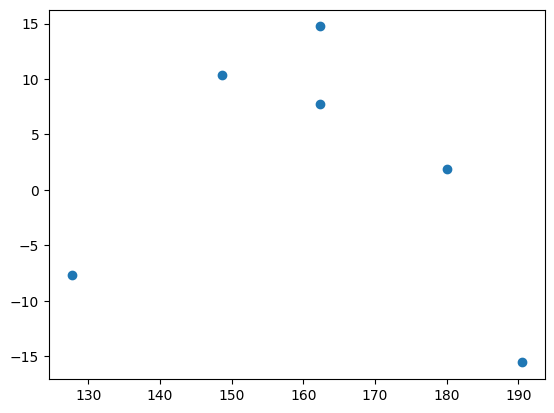

In [51]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)

## Using OLS

In [40]:
import statsmodels.api as sm

In [43]:
model = sm.OLS(y_train, X_train).fit()
predictions = model.predict(X_test) 
print(predictions)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [44]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 29 Jul 2025   Prob (F-statistic):                       0.664
Time:                        19:56:12   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [52]:
regressor.coef_

array([17.2982057])